<a href="https://colab.research.google.com/github/anjicx/CNHypergraph/blob/main/Histograms.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import os
from pathlib import Path
import warnings

import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import matplotlib.ticker as mtick

from IPython.display import display, Image

warnings.filterwarnings("ignore")

#config

# Mount Google Drive only if running in Colab
try:
    from google.colab import drive
    drive.mount("/content/drive", force_remount=False)
except ImportError:
    print("Not running in Colab. Skipping Google Drive mount.")

BASE_DIR = Path(
    os.environ.get(
        "PATIENT_DATA_DIR",
        "/content/drive/MyDrive/PatientData"
    )
).expanduser().resolve()

RAW_DATA_DIR = BASE_DIR / "raw_data"
HYPERGRAPH_DIR = BASE_DIR / "saved_hypergraphs"
STATISTICS_DIR = BASE_DIR / "hgnn_statistics"
PLOTS_DIR = BASE_DIR / "plots"

HYPERGRAPH_DIR.mkdir(parents=True, exist_ok=True)
STATISTICS_DIR.mkdir(parents=True, exist_ok=True)
PLOTS_DIR.mkdir(parents=True, exist_ok=True)

# Histograms notebook reads hypergraph outputs from FirstScript
input_dir = HYPERGRAPH_DIR

# Histograms notebook saves plots here
plot_dir = PLOTS_DIR / "histograms"
plot_dir.mkdir(parents=True, exist_ok=True)

print("BASE_DIR:", BASE_DIR)
print("RAW_DATA_DIR:", RAW_DATA_DIR)
print("HYPERGRAPH_DIR:", HYPERGRAPH_DIR)
print("STATISTICS_DIR:", STATISTICS_DIR)
print("PLOTS_DIR:", PLOTS_DIR)
print("Histogram plots will be saved to:", plot_dir)

Mounted at /content/drive
BASE_DIR: /content/drive/MyDrive/PatientData
RAW_DATA_DIR: /content/drive/MyDrive/PatientData/raw_data
HYPERGRAPH_DIR: /content/drive/MyDrive/PatientData/saved_hypergraphs
STATISTICS_DIR: /content/drive/MyDrive/PatientData/hgnn_statistics
PLOTS_DIR: /content/drive/MyDrive/PatientData/plots
Histogram plots will be saved to: /content/drive/MyDrive/PatientData/plots/histograms


In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import math

stays = pd.read_csv(RAW_DATA_DIR / "final_one_percent_stays.csv", sep=";")
age = pd.read_csv(RAW_DATA_DIR / "table_age.csv", sep=";", encoding="latin1")

How long these patients occure in dataset?
Patients age is the age of his first visit, and numbers of years=last visit day-first visit day (how long the patient is followed in data).


In [ ]:
stays = stays.merge(age, on="ag_id", how="left")#merging age group
stays = stays.rename(columns={"age": "age_group"})
#taking men/women nonbinary has 43261 and is not therefore included
staysHistogram = stays[["patient_no", "entry_date", "exit_date", "sex_id","age_group"]].copy()
staysHistogram = staysHistogram[staysHistogram["sex_id"].isin([1, 2])].copy()#only 1 and 2 later 1=male and 2 is female
#print(staysHistogram["sex_id"].value_counts(dropna=False).sort_index())

In [ ]:
#dates to real dates
staysHistogram["entry_date"] = pd.to_datetime(staysHistogram["entry_date"])
staysHistogram["exit_date"] = pd.to_datetime(staysHistogram["exit_date"])
staysHistogram["exit_date"] = staysHistogram["exit_date"].fillna(staysHistogram["entry_date"])#if exit day is missing use the same date as entering

#sort by patient and date
staysHistogram = staysHistogram.sort_values(["patient_no", "entry_date"])

#first and last date from patient counting:last day-first day/365.25 is no.of years per patient
patient_years = staysHistogram.groupby("patient_no").agg(
    first_date=("entry_date", "min"),
    last_date=("exit_date", "max")
).reset_index()

#years per patient
patient_years["years_per_patient"] = (
    patient_years["last_date"] - patient_years["first_date"]
).dt.days / 365.25

#from first visit for patient get age and gender
#first_visit = staysHistogram.groupby("patient_no").first().reset_index()[["patient_no", "sex_id", "age_group"] might take with all values first

first_visit = staysHistogram.drop_duplicates("patient_no", keep="first")[["patient_no", "sex_id", "age_group"]]
#one patient table
patient_data = patient_years.merge(first_visit, on="patient_no", how="left")

#se label for patient_data

patient_data["sex"] = patient_data["sex_id"].map({
    1: "Male",
    2: "Female"
})

In [ ]:
# count number of visits per patient
visit_counts = staysHistogram.groupby("patient_no").size().reset_index(name="n_visits")
# add visit count
patient_data = patient_data.merge(visit_counts, on="patient_no", how="left")
# keep only patients with at least 2 visits
patient_data = patient_data[patient_data["n_visits"] >= 2].copy()

HERE IT SAVES FILES

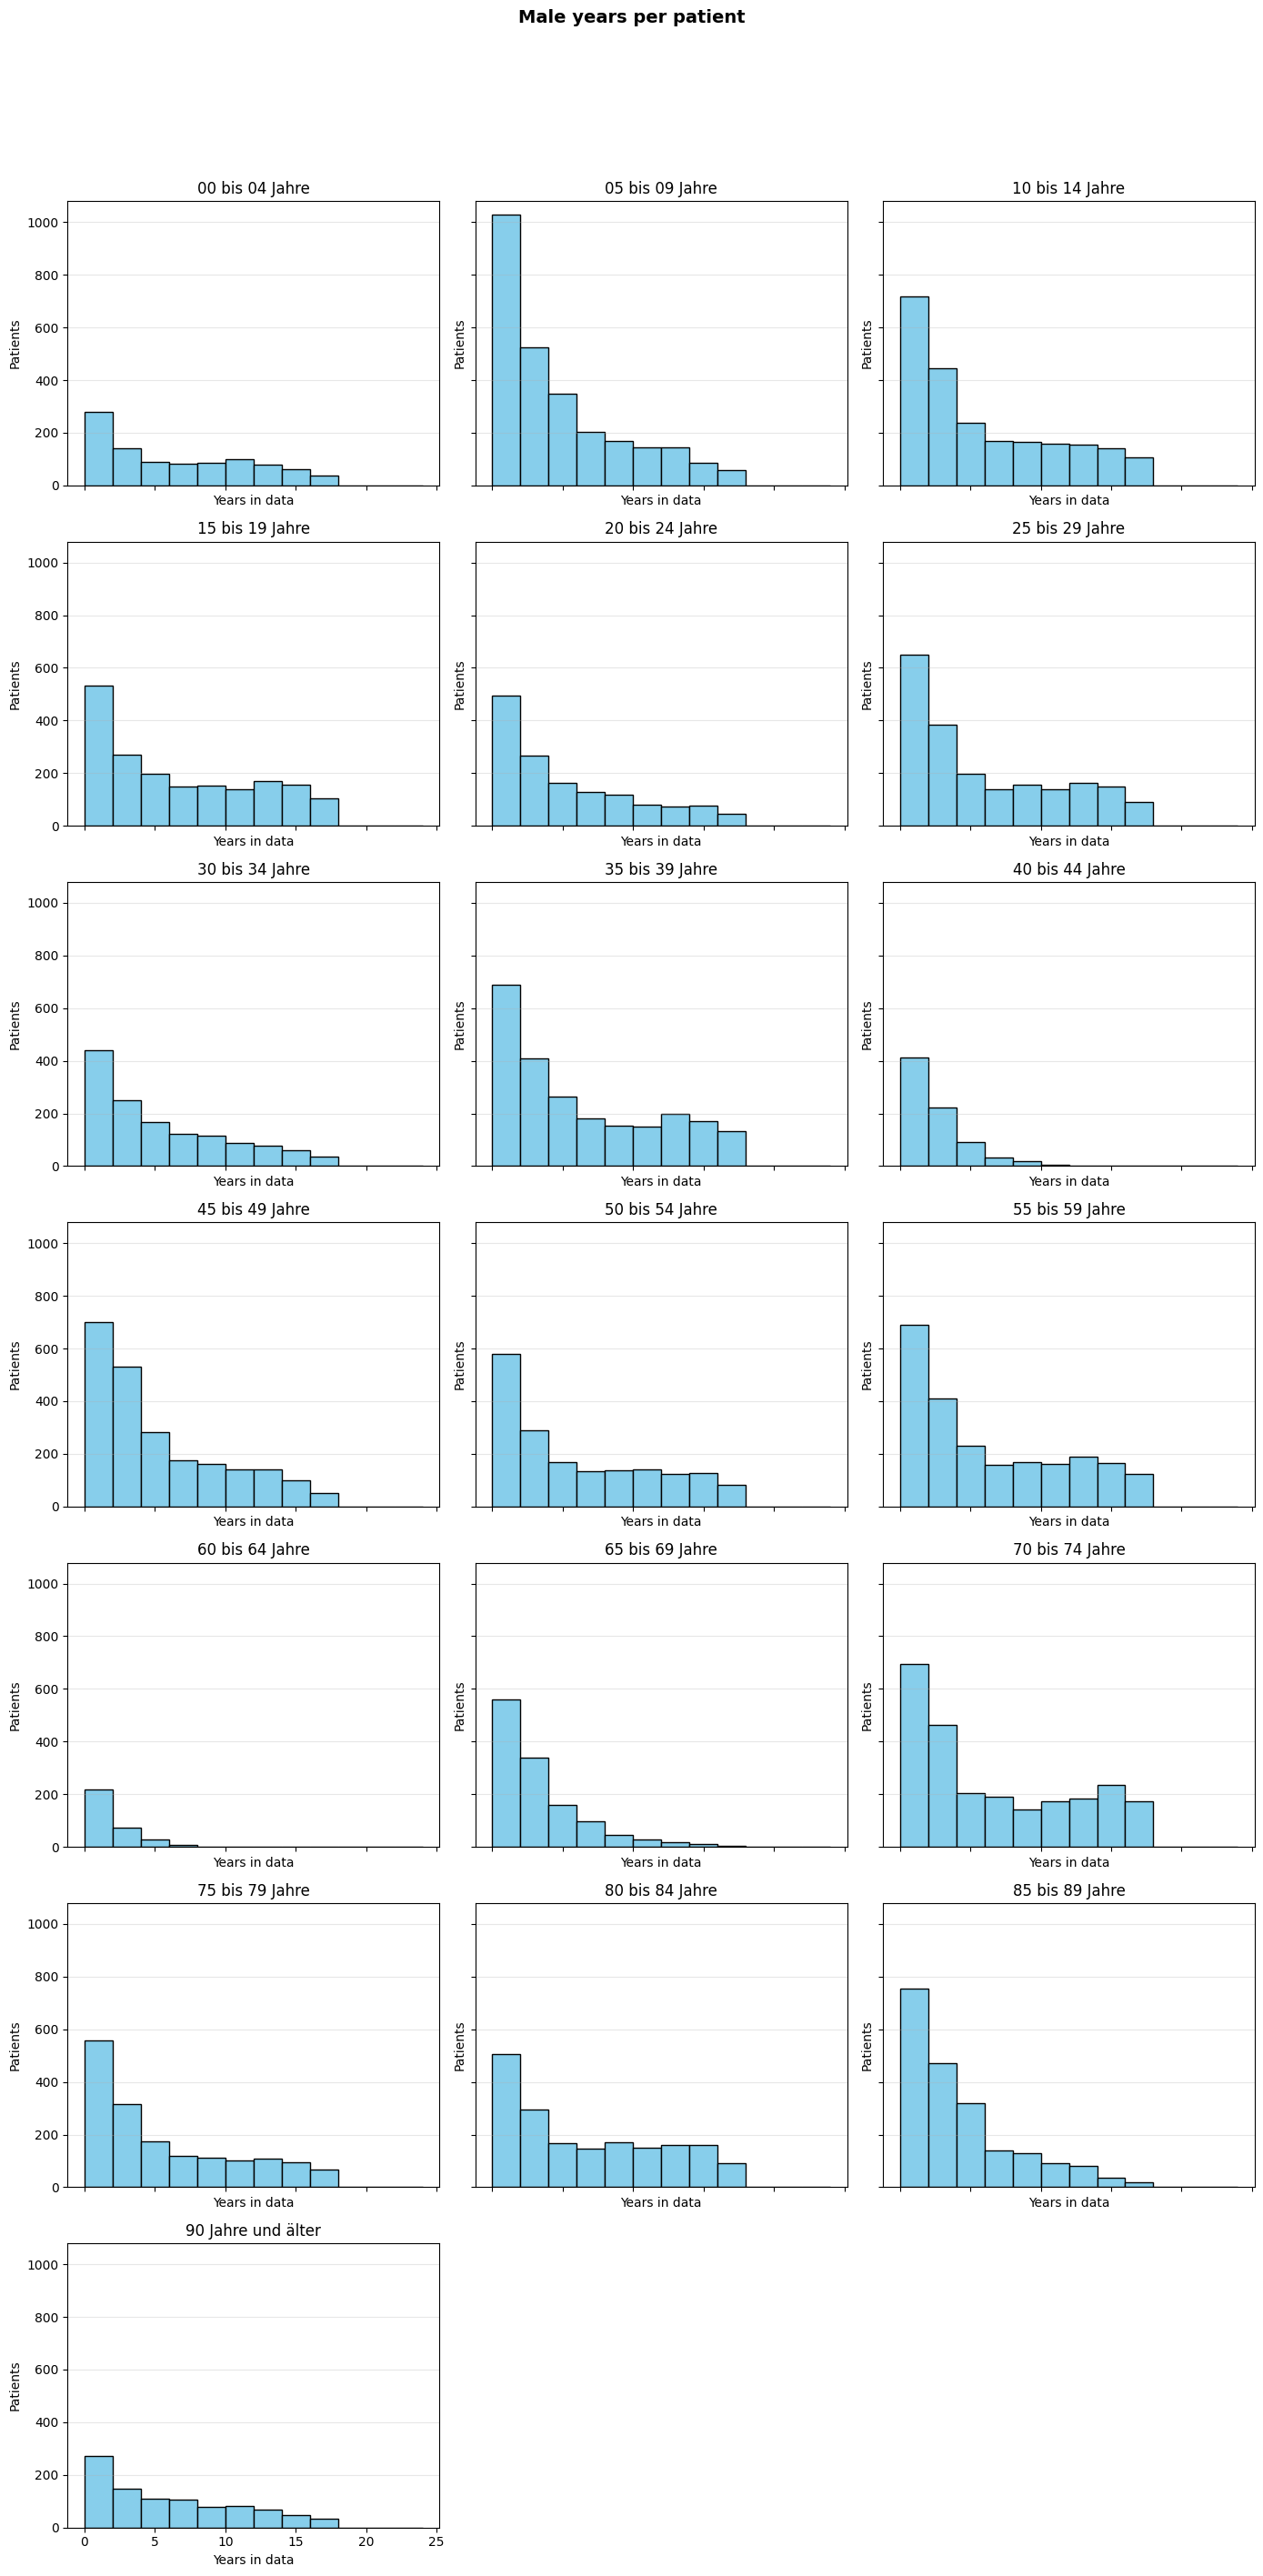

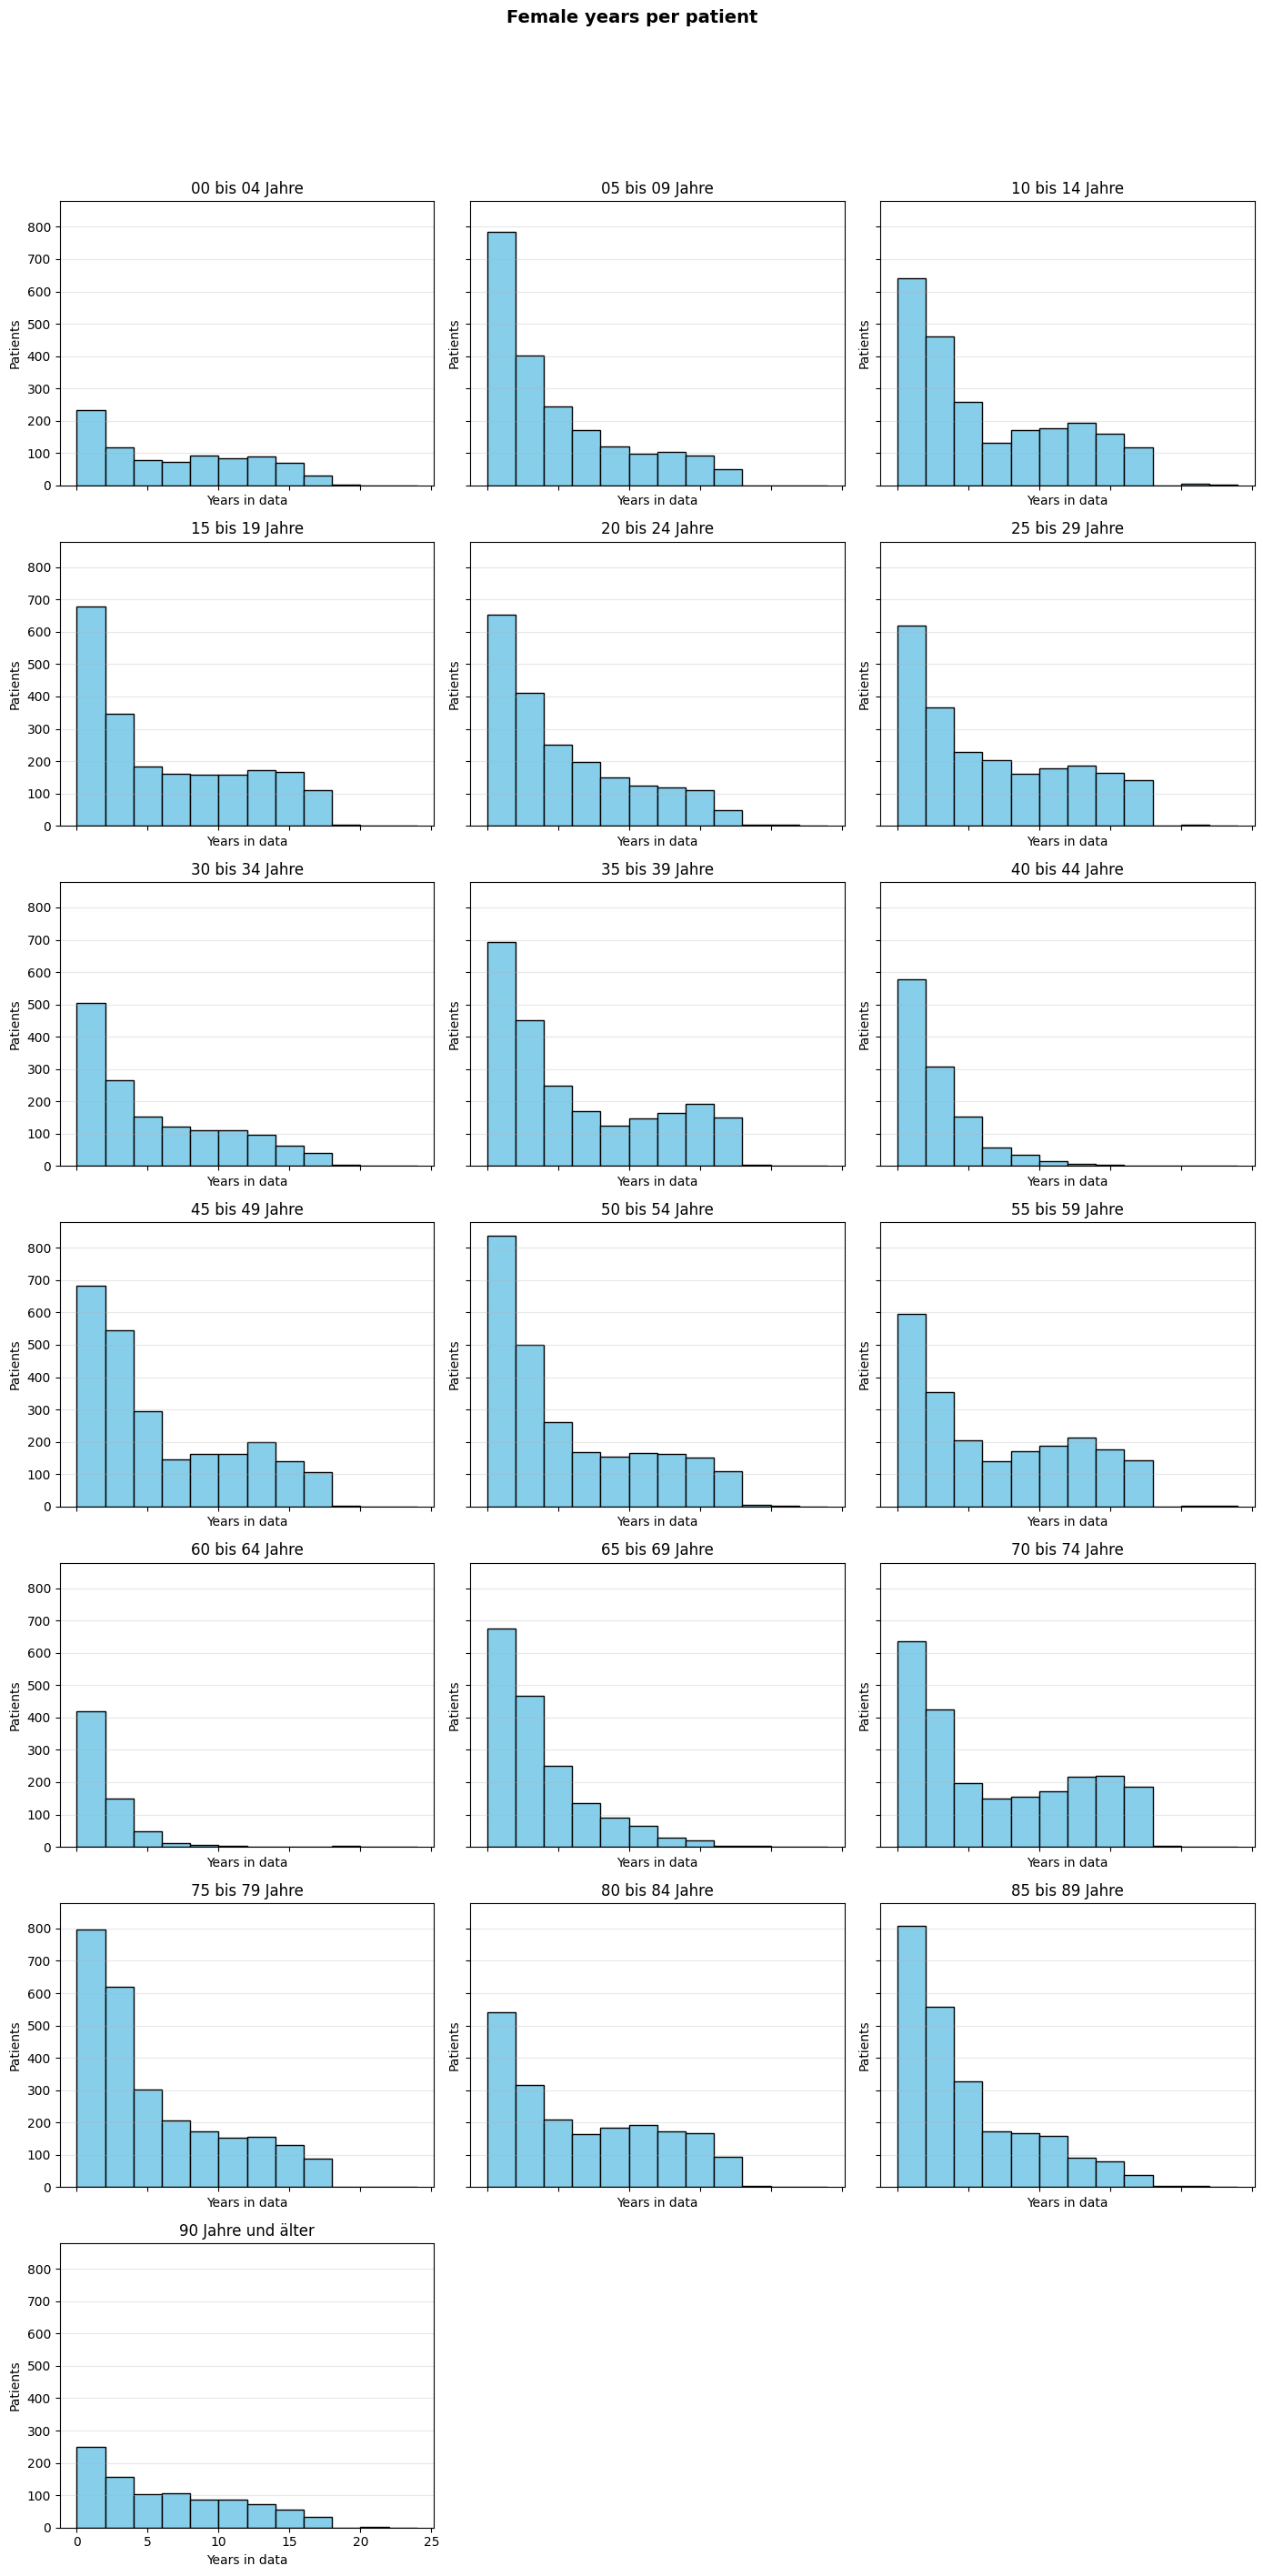

In [ ]:
import numpy as np
def plot_by_sex(sex_value, bin_width=2):
    sub = patient_data[patient_data["sex"] == sex_value].copy()
    age_groups = sorted(sub["age_group"].dropna().unique())

    max_years = np.ceil(sub["years_per_patient"].max())
    bins = np.arange(0, max_years + bin_width, bin_width)

    n = len(age_groups)
    ncols = 3
    nrows = math.ceil(n / ncols)

    fig, axes = plt.subplots(
        nrows, ncols,
        figsize=(14, 4 * nrows),
        sharex=True,
        sharey=True
    )
    axes = np.array(axes).reshape(-1)

    for i, ag in enumerate(age_groups):
        vals = sub[sub["age_group"] == ag]["years_per_patient"].dropna()
        axes[i].hist(vals, bins=bins, color="skyblue", edgecolor="black")
        axes[i].set_title(ag)
        axes[i].set_xlabel("Years in data")
        axes[i].set_ylabel("Patients")
        axes[i].grid(axis="y", alpha=0.3)

    for j in range(i + 1, len(axes)):
        axes[j].set_visible(False)
    fig.suptitle(f"{sex_value} years per patient",fontsize=14, fontweight="bold", y=1.01)
    plt.tight_layout(rect=[0, 0, 1, 0.96])
    plt.savefig(plot_dir / f"years_{sex_value}.png", dpi=300, bbox_inches="tight")
    plt.close()

plot_by_sex("Male")
plot_by_sex("Female")

How many other age groups did the patient move through?


In [ ]:
first_age = first_visit[["patient_no", "age_group"]].rename(
    columns={"age_group": "first_age_group"}
)
#first age group and all visits
age_tracking = staysHistogram.merge(first_age, on="patient_no", how="left")

#only visits different then first one
other_age_visits = age_tracking[
    age_tracking["age_group"] != age_tracking["first_age_group"]
].copy()

#counting different age groups that patient had
other_age_counts = (
    other_age_visits.groupby("patient_no")["age_group"]
    .nunique()
    .reset_index(name="n_other_age_groups")
)

#merging into patient data
patient_data = patient_data.merge(other_age_counts, on="patient_no", how="left")

#if only appeared in 1group then 0
patient_data["n_other_age_groups"] = patient_data["n_other_age_groups"].fillna(0).astype(int)

other_age_lists = (
    other_age_visits.groupby("patient_no")["age_group"]
    .apply(lambda x: sorted(x.dropna().unique().tolist()))
    .reset_index(name="other_age_groups")
)

patient_data = patient_data.merge(other_age_lists, on="patient_no", how="left")
patient_data["other_age_groups"] = patient_data["other_age_groups"].apply(
    lambda x: x if isinstance(x, list) else []
)

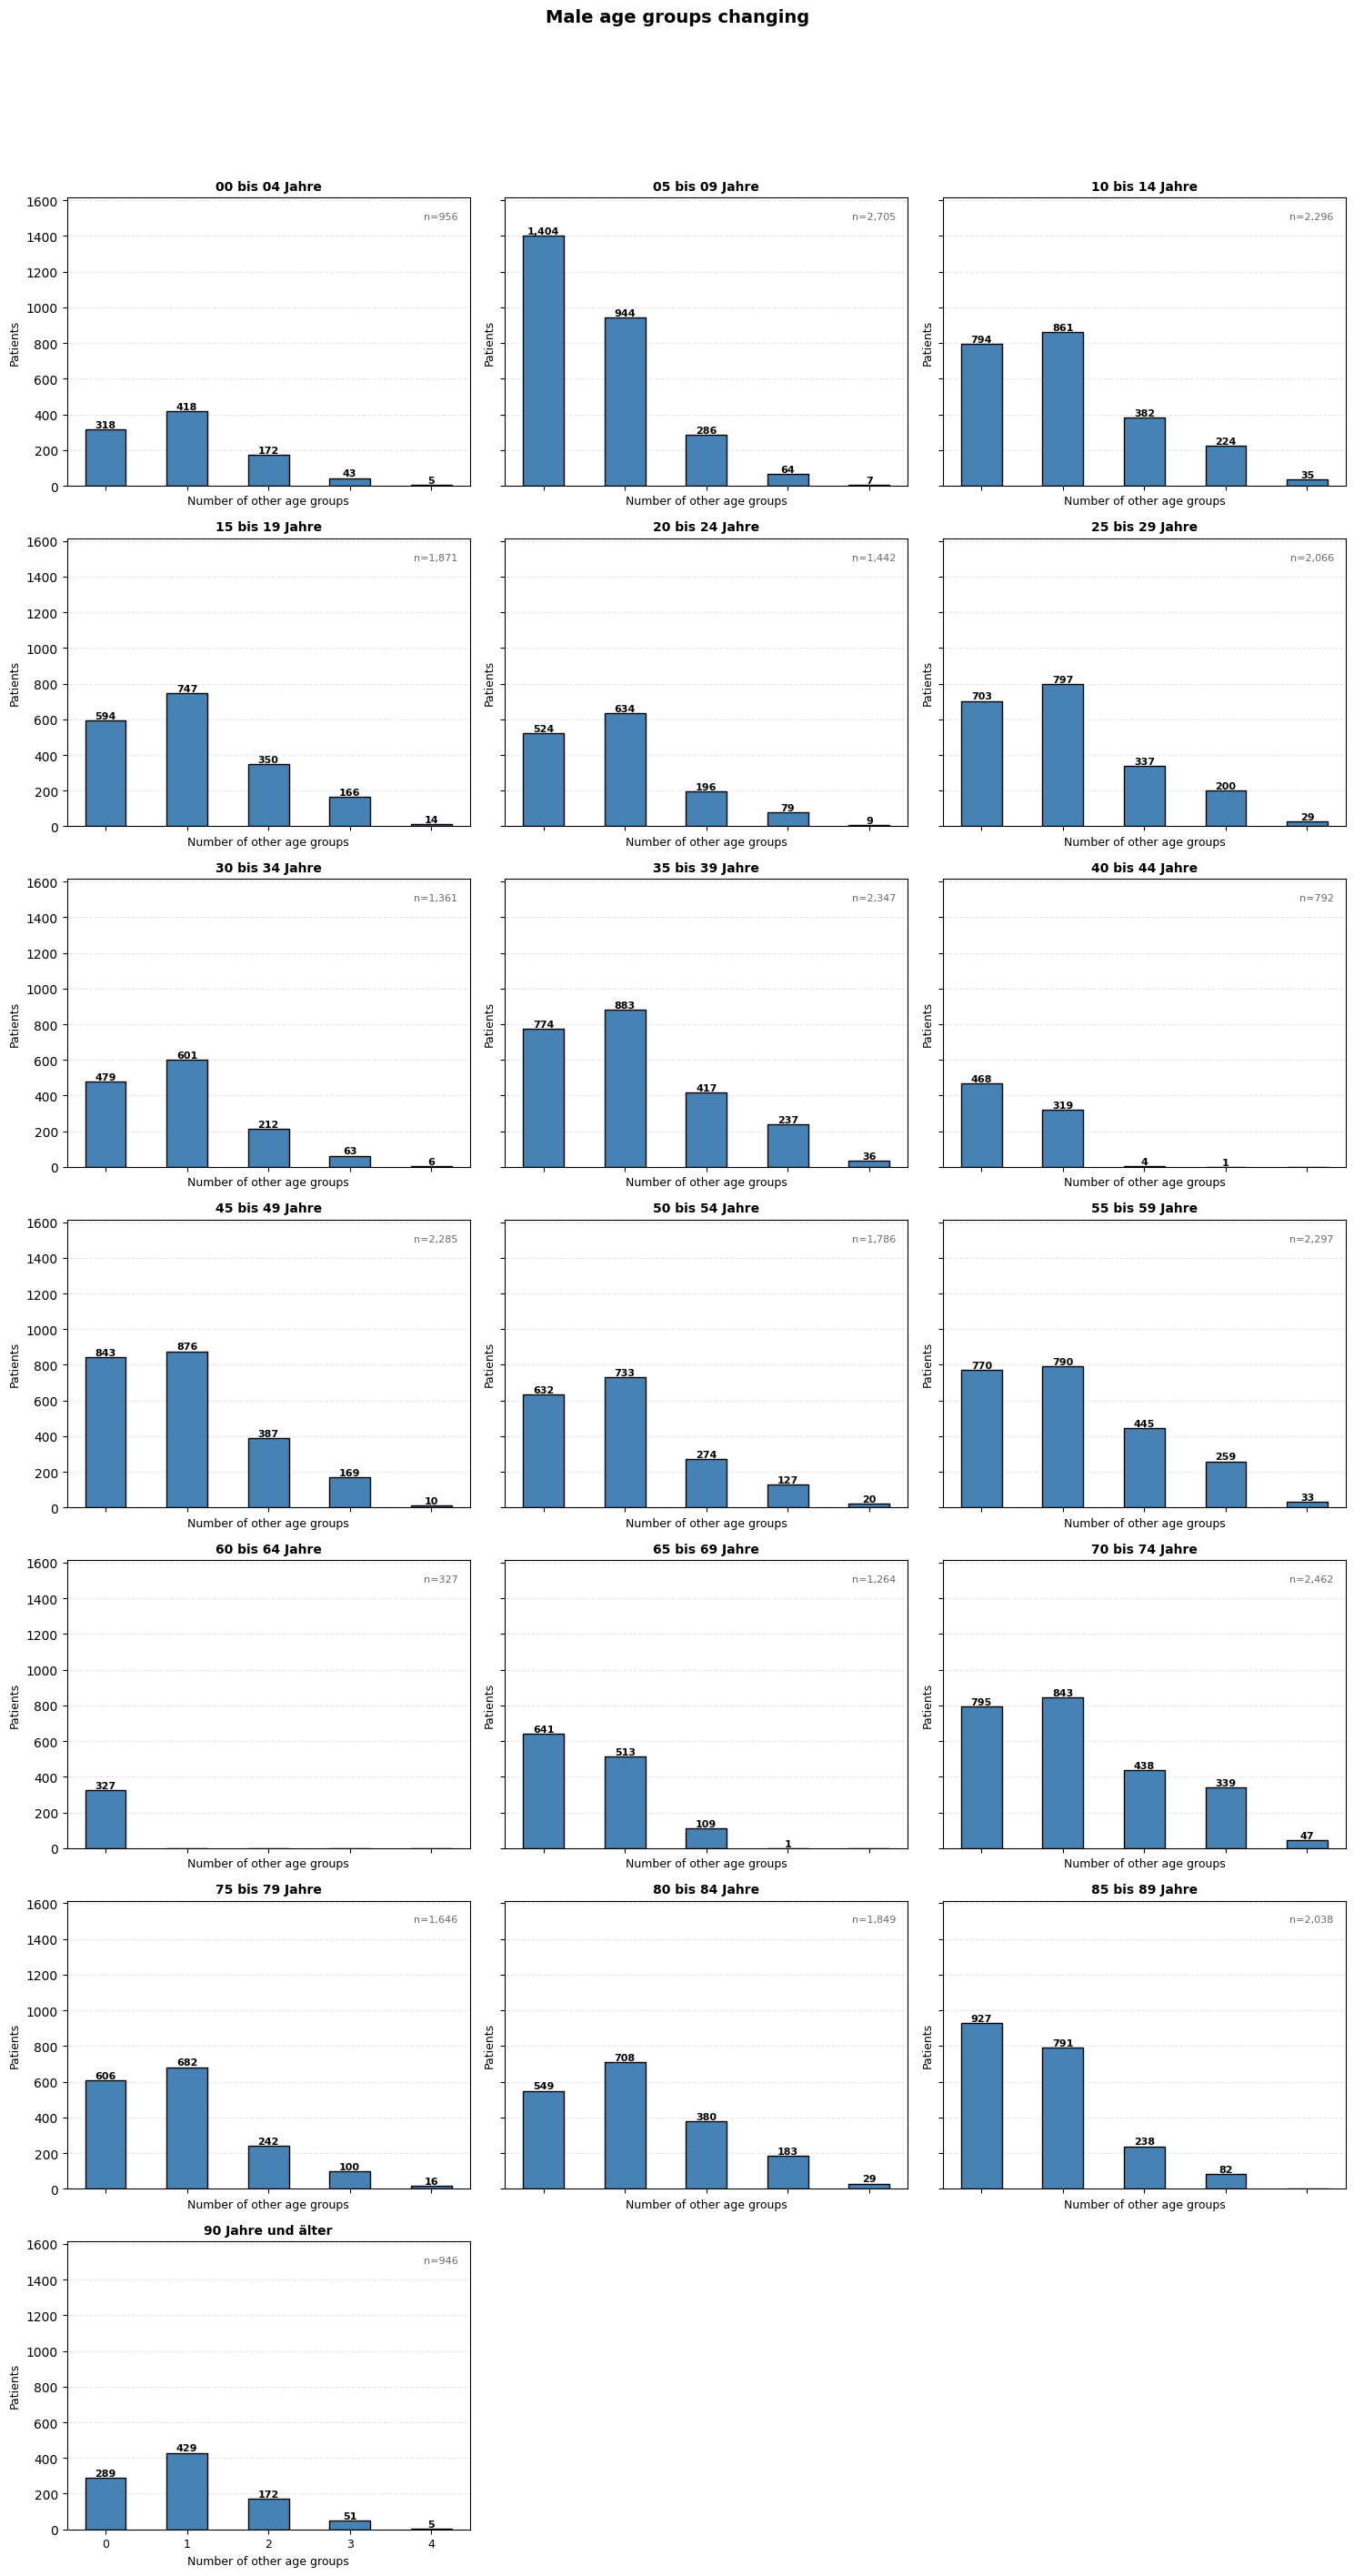

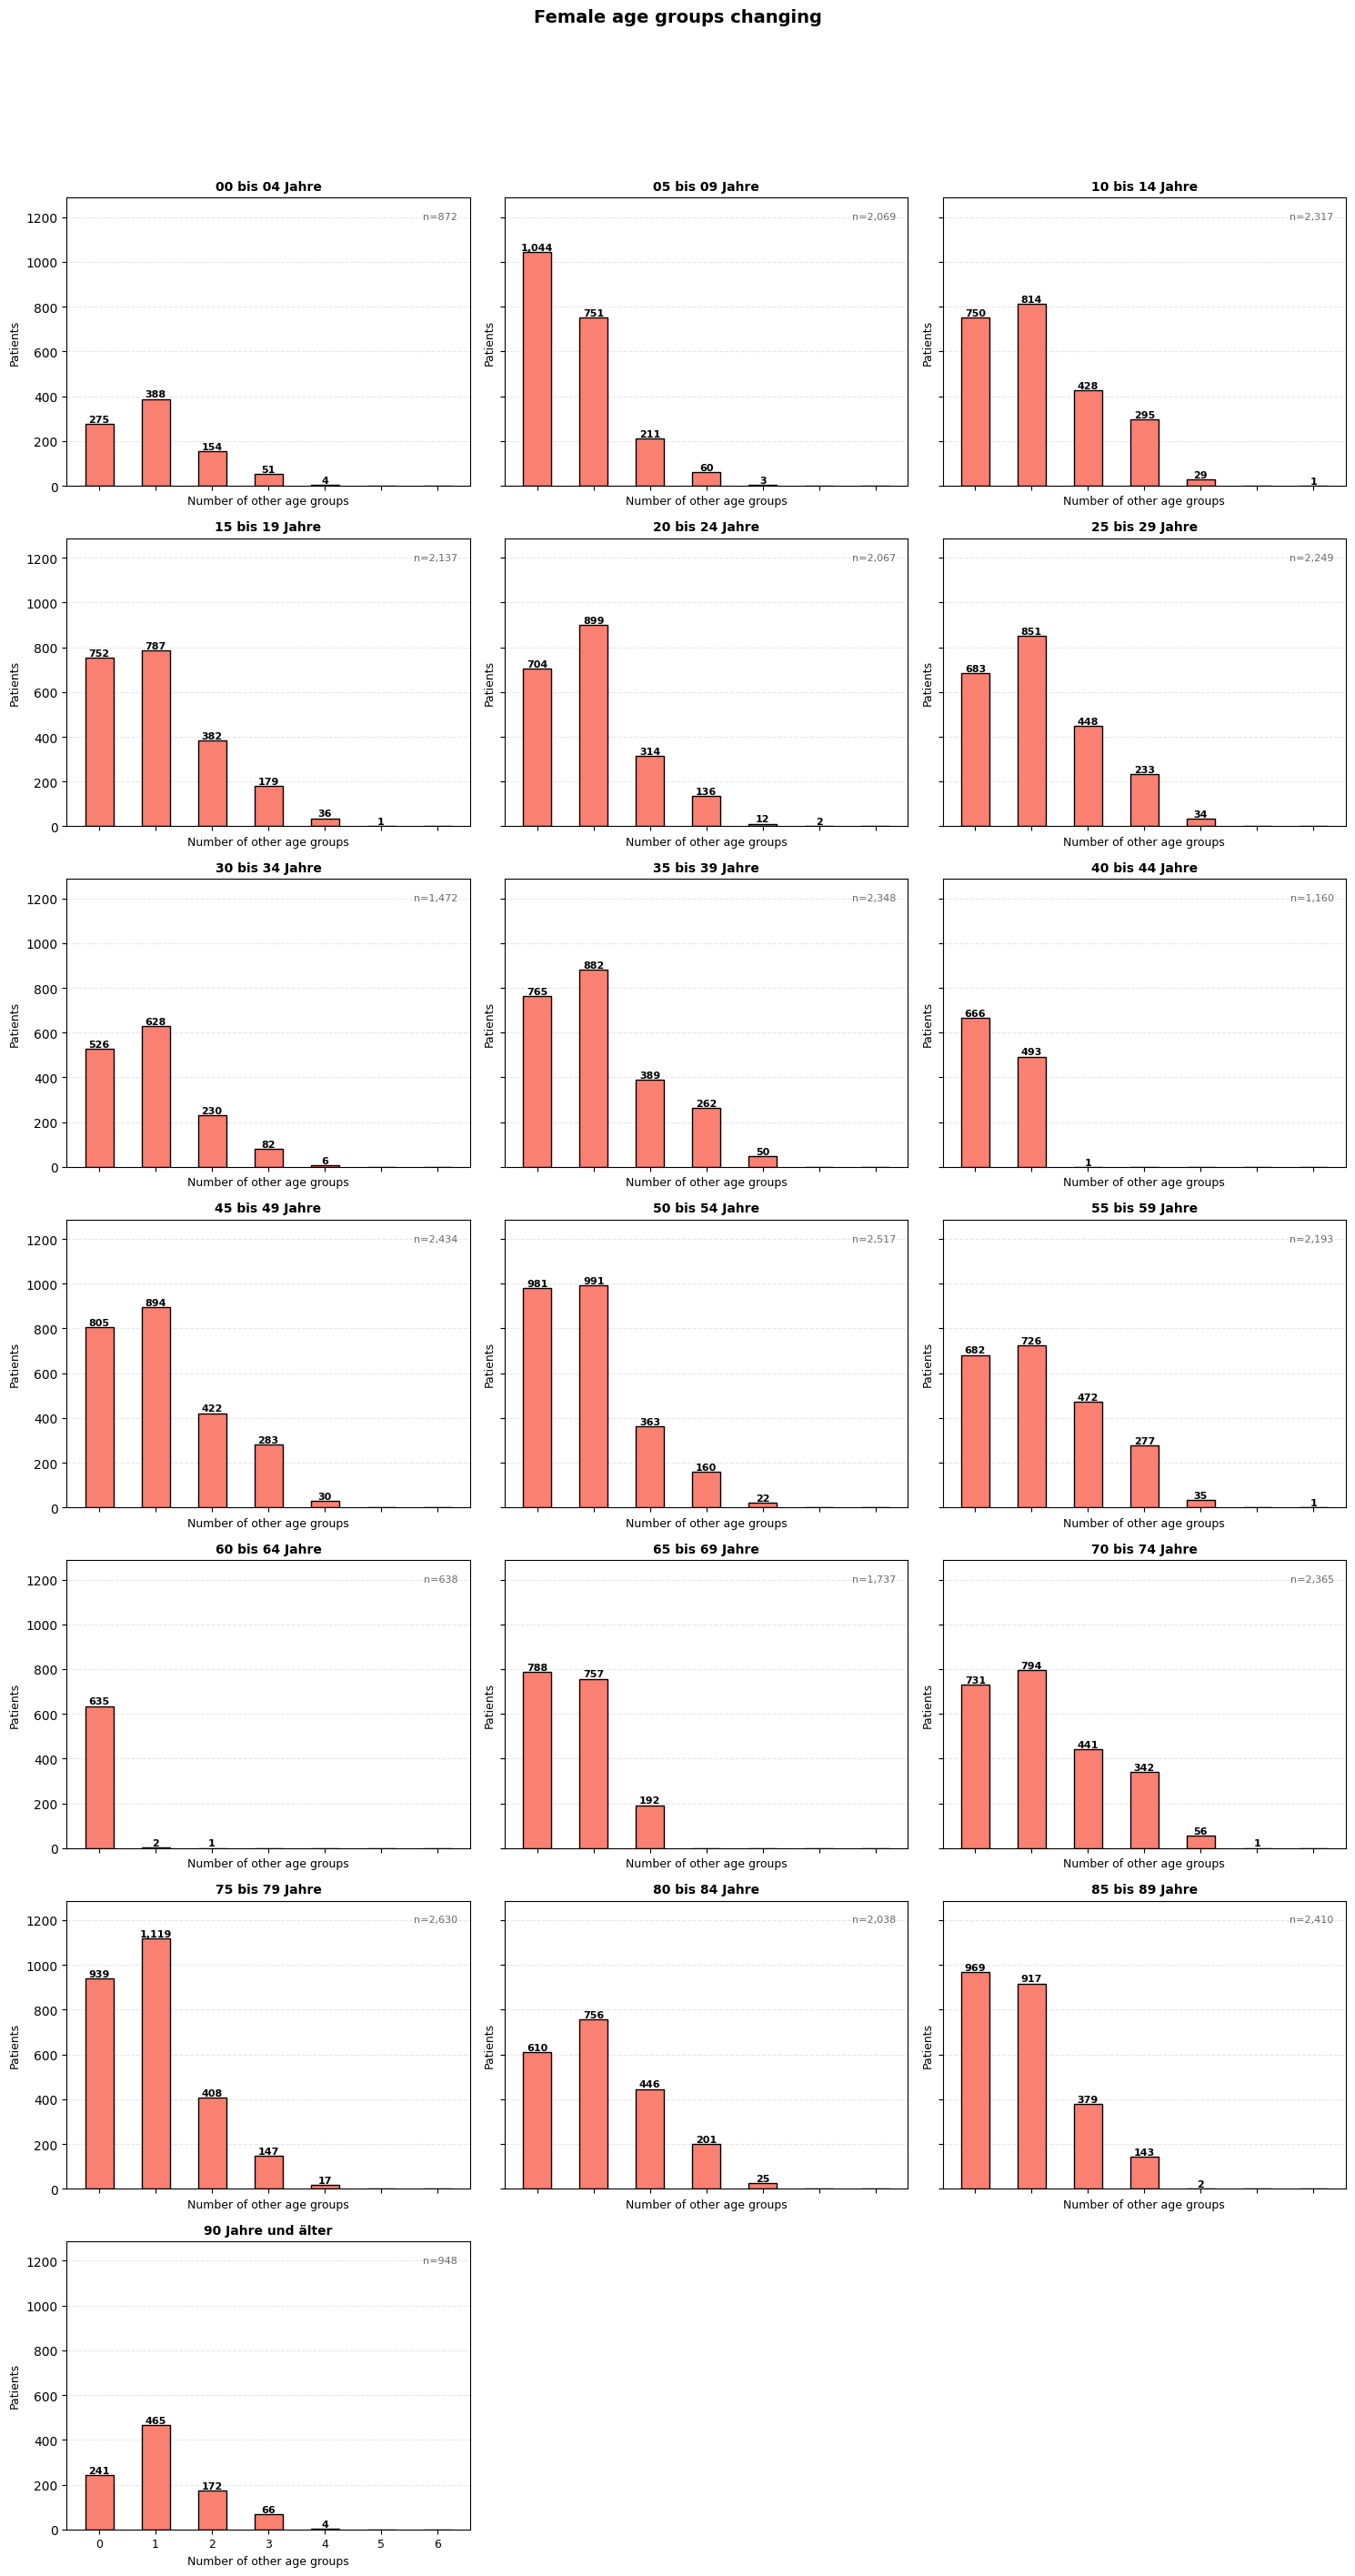

In [ ]:
def plot_other_age_groups_by_sex(sex_value):
    sub = patient_data[patient_data["sex"] == sex_value].copy()
    age_groups = sorted(sub["age_group"].dropna().unique())

    n = len(age_groups)
    ncols = 3
    nrows = math.ceil(n / ncols)

    max_count = int(sub["n_other_age_groups"].max())
    x_vals = list(range(0, max_count + 1))

    fig, axes = plt.subplots(
        nrows, ncols,
        figsize=(15, 4 * nrows),
        sharex=True,
        sharey=True
    )
    axes = np.array(axes).reshape(-1)

    for i, ag in enumerate(age_groups):
        ax = axes[i]

        vals = sub[sub["age_group"] == ag]["n_other_age_groups"]
        counts = vals.value_counts().sort_index().reindex(x_vals, fill_value=0)

        bars = ax.bar(
            counts.index, counts.values,
            color="steelblue" if sex_value == "Male" else "salmon",
            edgecolor="black",
            width=0.5
        )

        for bar, val in zip(bars, counts.values):
            if val > 0:
                ax.text(
                    bar.get_x() + bar.get_width() / 2,
                    bar.get_height() + 0.5,
                    f"{val:,}",
                    ha="center", va="bottom",
                    fontsize=8, fontweight="bold"
                )

        ax.set_title(ag, fontsize=10, fontweight="bold")
        ax.set_xlabel("Number of other age groups", fontsize=9)
        ax.set_ylabel("Patients", fontsize=9)
        ax.set_xticks(x_vals)
        ax.set_xticklabels([str(x) for x in x_vals], fontsize=9)
        ax.grid(axis="y", alpha=0.3, linestyle="--")
        ax.set_axisbelow(True)
        ax.margins(y=0.15)

        ax.text(
            0.97, 0.95, f"n={len(vals):,}",
            transform=ax.transAxes,
            fontsize=8, va="top", ha="right", color="dimgray"
        )

    for j in range(i + 1, len(axes)):
        axes[j].set_visible(False)

    fig.suptitle(f"{sex_value} age groups changing", fontsize=14, fontweight="bold", y=1.01)
    plt.tight_layout(rect=[0, 0, 1, 0.96])
    plt.savefig(plot_dir / f"other_age_groups_{sex_value}.png", dpi=300, bbox_inches="tight")
    plt.close()

plot_other_age_groups_by_sex("Male")
plot_other_age_groups_by_sex("Female")

How many other time periods did the patient appear in?

In [ ]:
staysHistogram["period"] = staysHistogram["entry_date"].dt.year #year he came into the hospital

first_period = staysHistogram.groupby("patient_no").first().reset_index()[[
    "patient_no", "period"
]].rename(columns={"period": "first_period"})

period_tracking = staysHistogram.merge(first_period, on="patient_no", how="left")

other_period_visits = period_tracking[
    period_tracking["period"] != period_tracking["first_period"]
].copy()

other_period_counts = (
    other_period_visits.groupby("patient_no")["period"]
    .nunique()
    .reset_index(name="n_other_periods")
)
patient_data_period = patient_data.copy()

patient_data_period = patient_data_period.merge(other_period_counts, on="patient_no", how="left")
patient_data_period["n_other_periods"] = patient_data_period["n_other_periods"].fillna(0).astype(int)
patient_data_period = patient_data_period.merge(first_period, on="patient_no", how="left")
patient_data_period = patient_data_period[patient_data_period["first_period"] >= 1997].copy()


In [ ]:
def plot_other_periods_by_sex(sex_value):
    sub = patient_data_period[patient_data_period["sex"] == sex_value].copy()
    periods = sorted(sub["first_period"].dropna().unique())

    n = len(periods)
    ncols = 3
    nrows = math.ceil(n / ncols)

    max_count = int(sub["n_other_periods"].max())
    x_vals = list(range(0, max_count + 1))

    fig, axes = plt.subplots(nrows, ncols, figsize=(15, 4 * nrows), sharex=True, sharey=True)
    axes = np.array(axes).reshape(-1)

    for i, p in enumerate(periods):
        ax = axes[i]

        vals = sub[sub["first_period"] == p]["n_other_periods"]
        counts = vals.value_counts().sort_index().reindex(x_vals, fill_value=0)

        bars = ax.bar(counts.index, counts.values, edgecolor="black")

        for bar, val in zip(bars, counts.values):
            if val > 0:
                ax.text(
                    bar.get_x() + bar.get_width()/2,
                    bar.get_height() + 0.5,
                    str(val),
                    ha="center", va="bottom", fontsize=8
                )

        ax.set_title(str(p))
        ax.set_xlabel("n other periods")
        ax.set_ylabel("Patients")
        ax.set_xticks(x_vals)
        ax.grid(axis="y", alpha=0.3)

    for j in range(i + 1, len(axes)):
        axes[j].set_visible(False)

    fig.suptitle(f"{sex_value} period changing", y=1.02)
    plt.tight_layout(rect=[0, 0, 1, 0.96])
    plt.savefig(plot_dir / f"other_periods_{sex_value}.png", dpi=300, bbox_inches="tight")
    pplt.close()